In [1]:
import os
import re
import nltk
from nltk import Tree

import spacy
#spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq
import ast
from matplotlib.lines import Line2D

plt.style.use("seaborn-v0_8-whitegrid")

## Load datasets

### Analysed datasets

In [2]:
# generated corpus
generated_corpus = load_dataset('roneneldan/TinyStories', split='train[:1%]')
df_generated = pd.DataFrame(generated_corpus['text'], columns=['story'])
sample_generated = df_generated.sample(1200)
print(f'Length of retrieved dataset: {len(generated_corpus)}.\nLength of sample: {len(sample_generated)}')

Length of retrieved dataset: 21197.
Length of sample: 1200


In [3]:
# real corpus
human_path = '/Users/sabijn/Documents/PhD/Datasets/CHILDES_Nicolopoulou'
human_corpus = pylangacq.read_chat(human_path)

df_human = pd.DataFrame({
	"story": [s.text() for s in human_corpus.stories()]
})

### Reference corpora

In [4]:
ref_standard_dep = Path('datasets/CommonCrawl/CC_dep_lexicon_100000_unk.csv')
ref_standard_uni = Path('datasets/CommonCrawl/CC_unigram_lexicon_100000.csv')
ref_standard_bi = Path('datasets/CommonCrawl/CC_bigram_lexicon_100000.csv')

In [5]:
ref_spoken_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CommonCrawl/CC_pos_bigram_100000.csv')
ref_spoken_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CommonCrawl/CC_pos_unigram_100000.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CommonCrawl/CC_pos_trigram_100000.csv')

## Story quality

Overview used metrics:
- Coherence
	- Local contextuality
- Grammaticality
	- Grammaticality
- Surprise
	- Creative perplexity
- Diversity
	- Lexical diversity: self-bleu
	- lexical diversity: moving mtld
- Complexity
	- Lexical complexity: unique words
	- Lexical complexity: Average word length
	- Syntactic complexity: avg. components
	- Syntactic complexity: dependency distance
	- Syntactic complexity: syntactic tree depth

In [6]:
eval_f = EvaluationFramework(language='en',
							  pos_unigram=ref_spoken_u_csv, 
							  pos_bigram=ref_spoken_b_csv,
							  pos_trigram=ref_spoken_t_csv,
							  ref_unigram=ref_standard_uni,
							  ref_bigram=ref_standard_bi,
							  ref_ling_constrained=ref_standard_dep,
							  embedding_model="all-MiniLM-L6-v2")

In [7]:
# Surprise: creative perplexity
eval_f.add_pipe('creative_perplexity_dep')
# Local contextuality
eval_f.add_pipe("local_contextuality")
# Grammaticality
eval_f.add_pipe('grammaticality')
# Diversity (lexical) self-bleu
eval_f.add_pipe('self-bleu')
# Diversity (lexical) moving mtld
eval_f.add_pipe('lexical_diversity')
# Complexity (lexical) unique words
eval_f.add_pipe('unique-words')
# Complexity (lexical) average word length
eval_f.add_pipe('avg-word-length')
# Complexity (syntactic)  average components
eval_f.add_pipe('average_components')
# Complexity (syntactic) dependency distance
eval_f.add_pipe('dependency_distance')
# Complexity (syntactic) syntactic tree depth
eval_f.add_pipe('syntactic_depth')

In [8]:
def load_or_run_eval(eval_f, dataset, column, path_name, *, run=False):
	if Path(path_name).exists() and not run:
		df = pd.read_csv(path_name)
		if 'lexical_diversity' in df.columns:
			df['lexical_diversity'] = df['lexical_diversity'].apply(ast.literal_eval)
			
		return df

	dataset = eval_f.run_pipeline_on_df(dataset, column)
	dataset.to_csv(path_name, index=False)
	return dataset

In [9]:
generated_eval_results = load_or_run_eval(eval_f, sample_generated, 'story', 'results/synthetic_eval_results_tinystories.csv')
generated_eval_results.columns

Index(['Unnamed: 0', 'story', 'creative_perplexity_dep', 'local_contextuality',
       'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length',
       'average_components', 'dependency_distance', 'syntactic_depth',
       'grammaticality'],
      dtype='object')

In [10]:
human_eval_results = load_or_run_eval(eval_f, df_human, 'story', 'results/human_eval_results_nicolopoulou.csv')
human_eval_results.columns

Index(['story', 'creative_perplexity_dep', 'local_contextuality',
       'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words',
       'avg-word-length', 'average_components', 'dependency_distance',
       'syntactic_depth'],
      dtype='object')

### Plotting story quality

In [11]:
nice_name = {'creative_perplexity_dep': 'Creative perplexity',
			 'local_contextuality': 'Local contextuality',
			 'grammaticality': 'Grammaticality',
			 'self-bleu': 'Self-bleu',
			 'lexical_diversity': 'Moving MTLD',
			 'unique-words': 'Size of vocabulary',
			 'avg-word-length': 'Average word length',
			 'average_components': 'Average components',
			 'dependency_distance': 'Dependency distance',
			 'syntactic_depth': 'Syntactic depth'
			 }

In [12]:
def get_value_from_dictionary(x, key):
	new = []

	for item in x:
		new.append(item[key])
	return new

In [13]:
statistics = {'human': defaultdict(tuple), 'generated': defaultdict(tuple)}
metrics = ['creative_perplexity_dep', 'local_contextuality', 'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length', 'average_components', 'dependency_distance', 'syntactic_depth']

for metric in generated_eval_results.columns:
	if metric == 'story':
		continue
	try:
		statistics['generated'][metric] = generated_eval_results[metric].mean()
	except:
		x = get_value_from_dictionary(generated_eval_results[metric], 'moving_mtld')
		statistics['generated'][metric] = np.mean(np.array(x))

for metric in human_eval_results.columns:
	if metric == 'story':
		continue
	human_eval_results[metric].dropna()
	try:
		statistics['human'][metric] = human_eval_results[metric].mean()
	except:
		x = get_value_from_dictionary(human_eval_results[metric], 'moving_mtld')
		statistics['human'][metric] = np.mean(np.array(x))

df_statistics = pd.DataFrame.from_dict(statistics, orient="index")

In [14]:
df_statistics

,creative_perplexity_dep,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth,Unnamed: 0
human,3807.651879,0.399560,-3.723612,0.233192,19.935355,30.279089,3.950424,0.041935,2.035285,2.242972,NaN
generated,317.753146,0.384186,-2.082383,0.173904,49.106473,92.768333,3.825336,0.528605,2.569537,3.451507,599.5


In [15]:
def radar_relative_change(
    df: pd.DataFrame,
    baseline: str,
    model: str,
    metric_rename: dict[str, str] | None = None,
    higher_is_better: dict[str, bool] | None = None,
    cap: float = 0.5,           # cap relative change at ±50%
    figsize=(7, 7),
    title: str | None = None,
    baseline_label: str | None = None,
    model_label: str | None = None,
):
    """
    df: rows=models, cols=metrics (raw values)
    baseline: index label of baseline row
    model: index label of model to compare
    """

    df_plot = df.copy()

    # Rename metrics early
    if metric_rename:
        df_plot = df_plot.rename(columns=metric_rename)

    # Extract rows
    base = df_plot.loc[baseline]
    mod = df_plot.loc[model]

    # Direction handling: ensure higher = better
    if higher_is_better:
        for m, hib in higher_is_better.items():
            m2 = metric_rename.get(m, m) if metric_rename else m
            if m2 in df_plot.columns and hib is False:
                base[m2] = -base[m2]
                mod[m2] = -mod[m2]

    # Relative change
    rel = (mod - base) / base.abs()

    # Clip extreme values
    rel = rel.clip(-cap, cap)

    # Map [-cap, cap] → [0, 1] for plotting
    values = (rel + cap) / (2 * cap)

    metrics = list(values.index)
    n = len(metrics)

    if n < 3:
        raise ValueError("Radar plots need at least 3 metrics.")

    # Angles
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    # Close the loop
    plot_values = values.tolist()
    plot_values += plot_values[:1]

    # Baseline reference ring at 0.5
    baseline_ring = [0.5] * (n + 1)

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([f"-{cap * 100}%", baseline_label, f"+{cap * 100}%", ""])

    # Baseline ring
    ax.plot(angles, baseline_ring, linestyle="--", linewidth=1, color="gray")

    # Model
    ax.plot(angles, plot_values, linewidth=2, label=model_label)
    ax.fill(angles, plot_values, alpha=0.15)

    if title:
        ax.set_title(title, pad=20)

    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10), frameon=False)
    plt.tight_layout()
    plt.savefig('results/paper_plots/calibration_radar_plots.pdf')


In [16]:
rename_dict = {
    "creative_perplexity_dep": "Creative PPL.",
    "local_contextuality": "Local Contextuality",
    "grammaticality": "Grammaticality",
    "self-bleu": "Self-BLEU",
    "lexical_diversity": "Moving MTLD",
    "unique-words": "Amount of Unique Words",
    "avg-word-length": "Average Word Length",
    "average_components": "Average Components",
    "dependency_distance": "Dependency Distance",
    "syntactic_depth": "Syntactic Tree Depth",
}

higher_is_better = {
    "creative_perplexity_dep": True,
    "local_contextuality": True,
    "grammaticality": True,
    "self-bleu": False,
    "lexical_diversity": True,
    "unique-words": True,
    "avg-word-length": True,
    "average_components": True,
    "dependency_distance": True,
    "syntactic_depth": True,
}

### Gutenburg stories

In [17]:
included_book_titles = ['The Happy Prince', "Andersen's Fairy Tales", 'The Blue Fairy Book', 'The Adventures of Pinocchio',
'East Indian Stories', 'American Indian Stories', 'MERRY STORIES AND FUNNY PICTURES', 
"Childhood's Favorites and Fairy Stories",'The Wonderful Wizard of Oz', 'Celtic Stories', 'Our Children', 'The Little Lame Prince', 'The Prince and Betty',
'The Adventures of Sherlock Holmes', 'Peter Pan', 'The Secret Garden', 'The Jungle Book', 'The Adventures of Tom Sawyer', 'A Little Princess', 
'Little Women', 'Just So Stories', 'Moby-Dick', 'Treasure Island', 'The Idiot', 'A Tale of Two Cities', 'My Man Jeeves', 'Sense and Sensibility', 
'The Time Machine', 'The Velveteen Rabbit', 'The Book of Dragons', 'The Snow Image', 'The Magical Mimics in Oz',
'Russian Stories', 'Snow-White', 'A Dramatic Reader', 'A Christmas Hamper', "Aesop's Fables", 
"My Father's Dragon", 'The Peace Egg and Other tales', 'Indian Why Stories', 'Folk-Tales of the Khasis', 'The Paradise of Children', 'Wonder Stories',
'The Best American Humorous Short Stories', 'Hindu Tales from the Sanskrit', 'The Tale of Johnny Town-Mouse', 'The Little Red Hen', 'East of the Sun and West of the Moon',
'Among the Forest People', 'True Stories of Wonderful Deeds', 'English Fairy Tales', 'Simla Village Tales Or, Folk Tales from the Himalayas',
'Japanese Fairy Tales', 'Plain Tales of the North', 'The Wind in the Willows', 'A Supplementary Reader for the Fourth Year of School', 
'A Wonder-Book for Girls and Boys', 'Tanglewood Tales', 'The Pig Brother', "The World's Greatest Books", 'Goody Two-Shoes', 
'The Marvelous Exploits of Paul Bunyan', 'Christmas Every Day and Other Stories', "The Children's Book of Thanksgiving Stories"]

included_titles_cleaned = [title.lower().strip('.') for title in included_book_titles]

In [18]:
stories = {}
counter = []

with open(f'/Users/sabijn/Documents/PhD/Datasets/cleaned_merged_fairy_tales_without_eos.txt', 'r') as f:
	for i, line in enumerate(f.readlines()):
		potential_title = line.strip('.;\n ').lower()
		if i == 0:
			current_story = ''
			current_title = potential_title

		if potential_title in included_titles_cleaned:
			stories[current_title] = current_story
			current_story = ''
			current_title = potential_title
		else:
			current_story += line
	
	stories[current_title] = current_story

In [19]:
sub_titles = [
	"THE EMPEROR'S NEW CLOTHES ",
	"THE SWINEHERD ",
	"THE REAL PRINCESS ",
	"THE SHOES OF FORTUNE ",
	"THE FIR TREE ",
	"THE SNOW QUEEN ",
	"THE LEAP-FROG ",
	"THE ELDERBUSH ",
	"THE BELL ",
	"THE OLD HOUSE ",
	"THE HAPPY FAMILY ",
	"THE STORY OF A MOTHER ",
	"THE FALSE COLLAR ",
	"THE SHADOW ",
	"THE LITTLE MATCH GIRL ",
	"THE DREAM OF LITTLE TUK ",
	"THE NAUGHTY BOY ",
	"THE RED SHOES ",
	"THE BRONZE RING ",
	"PRINCE HYACINTH AND THE DEAR LITTLE PRINCESS ",
	"THE BLUE BELT ",
	"PRINCE LINDWORM ",
	"THE LASSIE AND HER GODMOTHER ",
	"THE HUSBAND WHO WAS TO MIND THE HOUSE ",
	"THE LAD WHO WENT TO THE NORTH WIND ",
	"THE THREE PRINCESSES OF WHITELAND ",
	"SORIA MORIA CASTLE ",
	"THE GIANT WHO HAD NO HEART IN HIS BODY ",
	"THE PRINCESS ON THE GLASS HILL ",
	"THE WIDOW'S SON ",
	"THE THREE BILLY-GOATS GRUFF ",
	"THE THREE PRINCESSES IN THE BLUE MOUNTAIN ",
	"THE CAT ON THE DOVREFELL ",
	"ONE'S OWN CHILDREN ARE ALWAYS PRETTIEST ",
	"THE UGLY DUCKLING.",
	"THE LITTLE PINE TREE ",
	"THE LITTLE MATCH GIRL.",
	"LITTLE RED RIDING-HOOD.",
	"THE APPLES OF IDUN.",
	"HOW THOR GOT THE HAMMER.",
	"THE HAMMER LOST AND FOUND.",
	"THE STORY OF THE SHEEP.",
	"THE GOOD SHIP ARGO.",
	"JASON AND THE HARPIES.",
	"THE BRASS BULLS.",
	"JASON AND THE DRAGON.",
	"THE FLAX ",
	"THE DAISY ",
	"THE PEA BLOSSOM ",
	"THE STORKS ",
	"THE WILD SWANS ",
	"THE LAST DREAM OF THE OLD OAK ",
	"THE PORTUGUESE DUCK ",
	"THE SNOW MAN ",
	"THE FARMYARD COCK AND THE WEATHERCOCK ",
	"THE LITTLE MERMAID ",
	"BUCKWHEAT ",
	"WHAT HAPPENED TO THE THISTLE ",
	"THE PEN AND THE INKSTAND ",
	"THE TEAPOT ",
	"SOUP FROM A SAUSAGE SKEWER ",
	"WHAT THE GOODMAN DOES IS ALWAYS RIGHT ",
	"THE OLD STREET LAMP ",
	"THE SHEPHERDESS AND THE CHIMNEY SWEEP ",
	"THE DROP OF WATER ",
	"THE METAL PIG ",
	"THE FLYING TRUNK ",
	"THE BUTTERFLY ",
	"THE GOBLIN AND THE HUCKSTER ",
	"EVERYTHING IN ITS RIGHT PLACE ",
	"GREAT CLAUS AND LITTLE CLAUS ",
	"THE THREE BEARS ",
	"CINDERELLA ",
	"THE THREE BROTHERS ",
	"THE WREN AND THE BEAR ",
	"CHICKEN-LICKEN ",
	"THE FOX AND THE CAT ",
	"THE RATS AND THEIR SON-IN-LAW ",
	"THE MOUSE AND THE SAUSAGE ",
	"JOHNNY AND THE GOLDEN GOOSE ",
	"TITTY MOUSE AND TATTY MOUSE ",
	"THE SPIDER AND THE FLEA ",
	"THE LITTLE SHEPHERD BOY ",
	"THE THREE SPINNERS ",
	"THE CAT AND THE MOUSE IN PARTNERSHIP ",
	"THE SWEET SOUP ",
	"THE STRAW THE COAL AND THE BEAN ",
	"WHY THE BEAR HAS A STUMPY TAIL ",
	"THE THREE LITTLE PIGS ",
	"CHILDREN'S FAVORITE POEMS ",
	"THE OWL AND THE PUSSY-CAT ",
	"TWINKLE, TWINKLE ",
	"THE THREE LITTLE KITTENS ",
	"(A CAT'S TALE, WITH ADDITIONS)",
	"THE LAND OF COUNTERPANE ",
	"THERE WAS A LITTLE GIRL ",
	"THE BOY WHO NEVER TOLD A LIE ",
	"THE UNSEEN PLAYMATE ",
	"I SAW THREE SHIPS ",
	"A WAS AN ANT ",
	"THE TABLE AND THE CHAIR ",
	"PRECOCIOUS PIGGY ",
	"A BOY'S SONG ",
	"BUTTERCUPS AND DAISIES ",
	"THE VIOLET ",
	"IF EVER I SEE ",
	"THE LITTLE LAND ",
	"A LOBSTER QUADRILLE ",
	"WHERE GO THE BOATS?",
	"THE WIND AND THE MOON ",
	"WHERE ARE YOU GOING, MY PRETTY MAID?",
	"THE LOST DOLL ",
	"FOREIGN LANDS ",
	"BED IN SUMMER ",
	"TRY AGAIN ",
	"A GOOD PLAY ",
	"GOOD NIGHT AND GOOD MORNING ",
	"THE WIND ",
	"THE SPIDER AND THE FLY ",
	"LET DOGS DELIGHT TO BARK AND BITE ",
	"CHILD'S EVENING HYMN ",
	"CHILDREN'S FAVORITE STORIES ",
	"HANSEL AND GRETEL ",
	"PUSS IN BOOTS ",
	"THE ELVES AND THE SHOEMAKER ",
	"HANS IN LUCK ",
	"BELLING THE CAT ",
	"JACK AND THE BEANSTALK ",
	"THE SLEEPING BEAUTY ",
	"OLD-FASHIONED POEMS ",
	"LIMERICKS ",
	"MORE LIMERICKS ",
	"THE DEAD DOLL ",
	"THE GOLDEN RULE ",
	"THANKSGIVING DAY ",
	"THE MAGPIE'S NEST ",
	"THE FAIRIES OF THE CALDON LOW ",
	"THE LAND OF STORY-BOOKS ",
	"A VISIT FROM ST. NICHOLAS ",
	"LITTLE ORPHANT ANNIE ",
	"THE CHATTERBOX ",
	"THE VOICE OF SPRING ",
	"THE HISTORY LESSON ",
	"SONG OF LIFE ",
	"THE GOOD TIME COMING ",
	"WINDY NIGHTS ",
	"THE WONDERFUL WORLD ",
	"HARK! HARK! THE LARK ",
	"JOG ON, JOG ON ",
	"MY SHADOW ",
	"BY COOL SILOAM'S SHADY RILL ",
	"THE WIND IN A FROLIC ",
	"THE GRAVES OF A HOUSEHOLD ",
	"WE ARE SEVEN ",
	"THE BETTER LAND ",
	"THE JUVENILE ORATOR ",
	"THE FOX AND THE CROW ",
	"THE USE OF FLOWERS ",
	"CONTENTED JOHN ",
	"THE OLD MAN'S COMFORTS, AND HOW HE GAINED THEM ",
	"THE FROST ",
	"THE BATTLE OF BLENHEIM ",
	"THE CHAMELEON ",
	"THE HARDY TIN SOLDIER ",
	"THUMBELINA ",
	"THE TINDER-BOX ",
	"BOOTS AND HIS BROTHERS ",
	"THE FISHERMAN AND HIS WIFE ",
	"LITTLE SNOW-WHITE ",
	"BEAUTY AND THE BEAST ",
	"THE HISTORY OF TOM THUMB ",
	"PINOCCHIO'S ADVENTURES IN WONDERLAND",
	"HOW THE CAMEL GOT HIS HUMP ",
	"HOW THE RHINOCEROS GOT HIS SKIN ",
	"HOW THE LEOPARD GOT HIS SPOTS ",
	"THE ELEPHANT’S CHILD ",
	"THE CAT THAT WALKED BY HIMSELF ",
	"THE PIED PIPER ",
	"THE GINGERBREAD MAN ",
	"THE TALE OF PETER RABBIT ",
	"THE STORY OF PETER PAN ",
	"THE BIRD WITH THE BROKEN WING ",
	"GOLDILOCKS, OR THE THREE BEARS ",
	"CHRISTMAS EVERY DAY.",
	"THE PUMPKIN-GLORY "
]

non_kids_books = [
	'moby-dick',
	'the idiot',
	'a tale of two cities',
	'my man jeeves',
	'sense and sensibility',
	'the time machine',
	'plain tales of the north',
	'the best american humorous short stories',
	"the world's greatest books",
]


In [20]:
kids_stories = {title: story for title, story in stories.items() if title not in non_kids_books}

In [21]:
counter = 0
filtered_kids_stories = {}
substory = False

for name, story in kids_stories.items():
	substory = False
	current_story = ''
	current_title = name
	
	# find substories
	for line in story.split('\n'):
		if line.startswith('BY') or line.startswith('ADAPTED'):
			continue

		if line in sub_titles:
			substory = True
			if current_story == '':
				current_title = line.strip('.;\n ').lower()
			else:
				filtered_kids_stories[current_title] = current_story
				current_title = line.strip('.;\n ').lower()
				current_story = ''
		else:
			current_story += line

	# clean-up
	if substory:
		filtered_kids_stories[current_title] = current_story
	else:
		filtered_kids_stories[name] = story

In [22]:
df_kids_stories = pd.DataFrame.from_dict(filtered_kids_stories, orient='index', columns=['value'])
df_kids_stories = df_kids_stories.reset_index().rename(columns={'index': 'title'})
df_kids_stories.rename(columns={'value':'story'}, inplace=True)
df_kids_stories

,title,story
0,the happy prince,"HIGH above the city, on a tall column, stood t..."
1,the emperor's new clothes,MANY years ago there was an emperor who was so...
2,the swineherd,THERE was once a poor prince who had a kingdom...
3,the real princess,THERE was once a prince who wanted to marry a ...
4,the shoes of fortune,I. A Beginning Every author has some peculiari...
...,...,...
228,the marvelous exploits of paul bunyan,Paul Bunyan \nScholars Say He is the Only Amer...
229,christmas every day and other stories,...
230,christmas every day,"The little girl came into her papa's study, as..."
231,the pumpkin-glory,The papa had told the story so often that the ...


In [23]:
df_kids_stories['story_length'] = df_kids_stories['story'].str.split().str.len()
df_kids_stories = df_kids_stories[df_kids_stories['story_length'] > 0]

df_short_kids = df_kids_stories[df_kids_stories['story_length'] < 10000].copy()

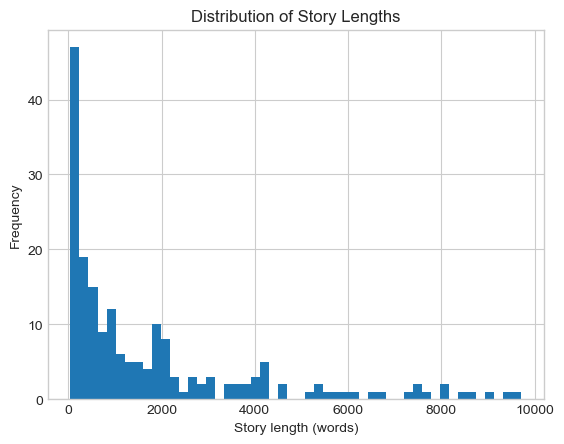

In [24]:
plt.figure()
plt.hist(df_short_kids['story_length'], bins=50)
plt.xlabel('Story length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Story Lengths')
plt.show()

In [25]:
gutenberg_eval_results = load_or_run_eval(eval_f, df_short_kids, 'story', 'results/human_eval_results_gutenberg.csv')
gutenberg_eval_results.columns

Index(['Unnamed: 0', 'title', 'story', 'story_length',
       'creative_perplexity_dep', 'local_contextuality', 'grammaticality',
       'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length',
       'average_components', 'dependency_distance', 'syntactic_depth'],
      dtype='object')

In [26]:
gutenberg_eval_results['grammaticality'] = gutenberg_eval_results.apply(lambda row: eval_f.run_component('grammaticality', row['story']), axis = 1)

In [27]:
metrics = ['creative_perplexity_dep', 'local_contextuality', 'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length', 'average_components', 'dependency_distance', 'syntactic_depth']
statistics['gutenberg'] = defaultdict(float)

for metric in gutenberg_eval_results.columns:
	if metric == 'story' or metric == 'title':
		continue
	try:
		statistics['gutenberg'][metric] = gutenberg_eval_results[metric].mean()
	except:
		x = get_value_from_dictionary(gutenberg_eval_results[metric], 'moving_mtld')
		statistics['gutenberg'][metric] = np.mean(np.array(x))

df_statistics = pd.DataFrame.from_dict(statistics, orient="index")

In [28]:
df_statistics.drop(columns=['Unnamed: 0'], inplace=True)

In [29]:
df_statistics

,creative_perplexity_dep,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth,story_length
human,3807.651879,0.399560,-3.723612,0.233192,19.935355,30.279089,3.950424,0.041935,2.035285,2.242972,NaN
generated,317.753146,0.384186,-2.082383,0.173904,49.106473,92.768333,3.825336,0.528605,2.569537,3.451507,NaN
gutenberg,489.244592,0.316282,-2.168156,0.240522,65.577474,493.531915,3.946345,0.775911,3.380378,4.295847,1810.654255


## Simlex

In [30]:
from gensim.models import Word2Vec
# from gensim.models.doc2vec import TaggedDocument
# from gensim.models import Doc2Vec
from sklearn.manifold import TSNE
from simplemma import text_lemmatizer
from adjustText import adjust_text

In [31]:
simlex999 = pd.read_csv('dataset_evaluation/modelasametric/SimLex-999.txt', names=['lemma1','lemma2', 'POS', 'SimLexScore', 'conc(w1)', 'conc(w2)', 'concQ', 'Assoc(USF)', 'SimAssoc333', 'SD(Simlex)'], skiprows=1, sep='\t')
simlex999

,lemma1,lemma2,POS,SimLexScore,conc(w1),conc(w2),concQ,Assoc(USF),SimAssoc333,SD(Simlex)
0,old,new,A,1.58,2.72,2.81,2,7.25,1,0.41
1,smart,intelligent,A,9.20,1.75,2.46,1,7.11,1,0.67
2,hard,difficult,A,8.77,3.76,2.21,2,5.94,1,1.19
3,happy,cheerful,A,9.55,2.56,2.34,1,5.85,1,2.18
4,hard,easy,A,0.95,3.76,2.07,2,5.82,1,0.93
...,...,...,...,...,...,...,...,...,...,...
994,join,acquire,V,2.85,2.86,2.93,2,0.00,0,0.99
995,send,attend,V,1.67,2.70,3.17,2,0.00,0,1.44
996,gather,attend,V,4.80,2.75,3.17,2,0.00,0,1.97
997,absorb,withdraw,V,2.97,3.11,3.04,2,0.00,0,1.75


In [32]:
# function to clean raw stories
def lemmatize(data):
    sents = []
    for story in data:
        lines = list(nlp(story).sents)
        for sent in lines:
            words = [w.lemma_.lower() for w in sent if w.is_alpha]
            sents.append(words)

    return sents

def train_and_save_w2v(data, save_name, callbacks=[]):
    if Path(save_name).exists():
        return Word2Vec.load(save_name)

    # list of sents of all stories
    sents = lemmatize(data)
    print(len(sents))
    # train w2v
    model = Word2Vec(sents, 
                        min_count=5, 
                        window=5, 
                        vector_size=100, 
                        negative=5, 
                        seed=42, 
                        workers=1, 
                        sg=0, 
                        alpha=0.001, 
                        epochs=500,
                        callbacks=callbacks)
    
    model.save(save_name)

    return model


In [33]:
def compute_similarity(lemma_list, model):
    pairs = lemma_list
    cos_sim = []

    for pair in pairs:
        cos_sim.append(model.wv.similarity(pair[0], pair[1]))

    return cos_sim

In [34]:
def select_invocab_simlex(simlex: pd.DataFrame, models: Word2Vec):
    vocab_sets = [set(model.wv.key_to_index) for model in models]
    shared_vocab = set.intersection(*vocab_sets)

    in_vocab_simlex = simlex[
        simlex["lemma1"].isin(shared_vocab) &
        simlex["lemma2"].isin(shared_vocab)
    ]

    # Outputs
    word_list = list(set(in_vocab_simlex["lemma1"]).union(in_vocab_simlex["lemma2"]))
    word_pairs = list(in_vocab_simlex[["lemma1", "lemma2"]].itertuples(index=False, name=None))

    return in_vocab_simlex, word_list, word_pairs

In [35]:
from itertools import combinations
from scipy.stats import spearmanr

def pairwise_spearman(sim_lists):
    """
    sim_lists: list of 1D arrays/lists, one per model.
               e.g. [sims_model1, sims_model2, sims_model3, ...]
    
    Returns: dict with ((i, j) -> spearman_r)
    """
    results = {}
    names = list(sim_lists.keys())
    similarities = list(sim_lists.values())

    for i, j in combinations(range(len(similarities)), 2):
        r, p = spearmanr(similarities[i], similarities[j])
        results[(names[i], names[j])] = {"rho": r, "p": p}

    return results

In [36]:
# initialise word2vec model
all_datasets = {'tinystories': sample_generated, 'gutenberg': df_short_kids}

trained_models = {}
for name, data in all_datasets.items():
    model = train_and_save_w2v(data['story'], f'dataset_evaluation/modelasametric/story_Word2Vec_{name}_mincount5.kv')
    trained_models[name] = model

23069


KeyboardInterrupt: 

In [ ]:
print(trained_models.values())

dict_values([<gensim.models.word2vec.Word2Vec object at 0x3765b4b90>, <gensim.models.word2vec.Word2Vec object at 0x3833dc140>])


In [ ]:
df_filtered_simlex, filtered_simlex_list, filtered_simlex_tuple = select_invocab_simlex(simlex999, trained_models.values())

In [ ]:
cosine_similarities = {}
for name, model in trained_models.items():
    print(name)
    cosine_similarities[name] = compute_similarity(filtered_simlex_tuple, model)

cosine_similarities['simlex999'] = df_filtered_simlex['SimLexScore']
statistic_results = pairwise_spearman(cosine_similarities)
statistic_results

tinystories
gutenberg


{('tinystories', 'gutenberg'): {'rho': 0.5993413014608233,
  'p': 7.224442009117252e-26},
 ('tinystories', 'simlex999'): {'rho': 0.22520916715716413,
  'p': 0.00032254461146289114},
 ('gutenberg', 'simlex999'): {'rho': 0.24642079222688038,
  'p': 7.961154891779351e-05}}

## Radarplots

In [37]:
def radar_relative_change(
    df: pd.DataFrame,
    baseline: str,
    model: str,
    metric_rename: dict[str, str] | None = None,
    higher_is_better: dict[str, bool] | None = None,
    cap: float = 0.5,           # cap relative change at ±50%
    figsize=(7, 7),
    title: str | None = None,
    baseline_label: str | None = None,
    model_label: str | None = None,
):
    """
    df: rows=models, cols=metrics (raw values)
    baseline: index label of baseline row
    model: index label of model to compare
    """

    df_plot = df.copy()

    # Rename metrics early
    if metric_rename:
        df_plot = df_plot.rename(columns=metric_rename)

    # Extract rows
    base = df_plot.loc[baseline]
    mod = df_plot.loc[model]

    # Direction handling: ensure higher = better
    if higher_is_better:
        for m, hib in higher_is_better.items():
            m2 = metric_rename.get(m, m) if metric_rename else m
            if m2 in df_plot.columns and hib is False:
                base[m2] = -base[m2]
                mod[m2] = -mod[m2]

    # Relative change
    rel = (mod - base) / base.abs()

    # Clip extreme values
    rel = rel.clip(-cap, cap)

    # Map [-cap, cap] → [0, 1] for plotting
    values = (rel + cap) / (2 * cap)

    metrics = list(values.index)
    n = len(metrics)

    if n < 3:
        raise ValueError("Radar plots need at least 3 metrics.")

    # Angles
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    # Close the loop
    plot_values = values.tolist()
    plot_values += plot_values[:1]

    # Baseline reference ring at 0.5
    baseline_ring = [0.5] * (n + 1)

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([f"-{cap * 100}%", "", "", "", f"+{cap * 100}%"])

    # Baseline ring
    ax.plot(angles, baseline_ring, linestyle="--", linewidth=2, color="tab:blue", label=baseline_label)
    ax.fill(angles, baseline_ring, alpha=0.15, color="tab:blue")

    # Model
    ax.plot(angles, plot_values, linewidth=2, label=model_label, color="tab:orange")
    ax.fill(angles, plot_values, alpha=0.15, color="tab:orange")

    if title:
        ax.set_title(title, pad=20)
    
    ax.tick_params(axis='both', which='major', labelsize=12)

    # # Remove radial grid lines (including outer circle)
    # ax.yaxis.grid(False)

    # Remove the polar spine (outer circle)
    ax.spines["polar"].set_visible(False)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10), frameon=False, fontsize=12)
    plt.tight_layout()
    plt.savefig('results/paper_plots/calibration_radar_plots.pdf')


In [42]:
df_statistics.drop(columns={'story_length'}, inplace=True)

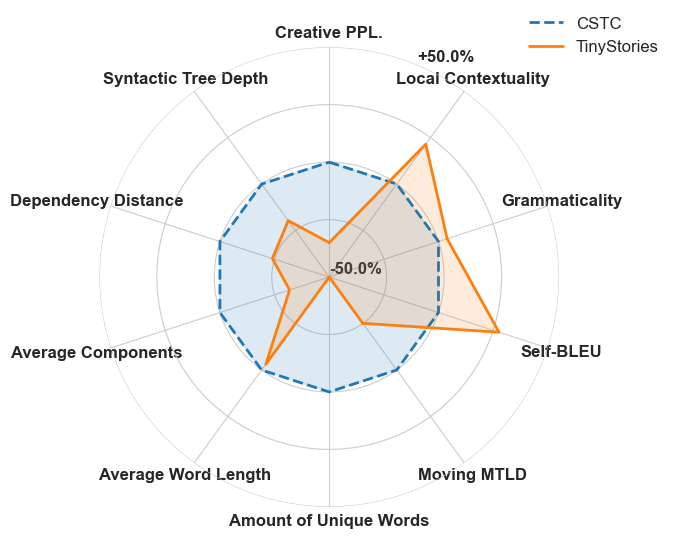

In [ ]:
radar_relative_change(
    df_statistics,
    baseline="gutenberg",
    model="generated",
    metric_rename=rename_dict,
    higher_is_better=higher_is_better,
    cap=0.5,
    baseline_label='CSTC',
    model_label='TinyStories'
)

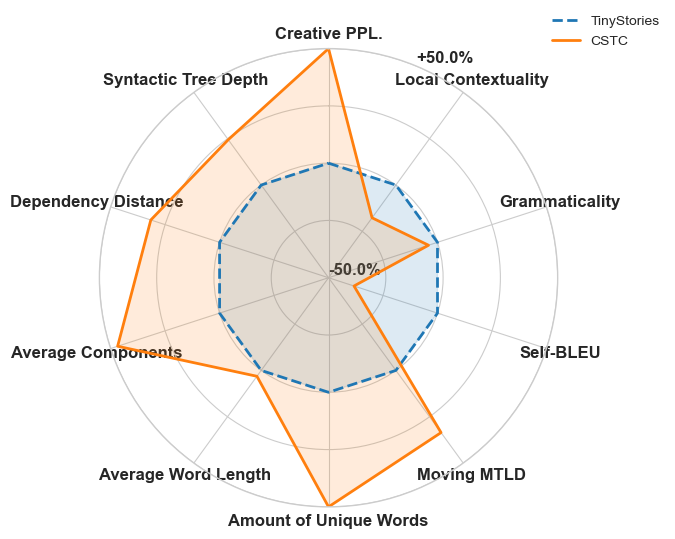

In [ ]:
radar_relative_change(
    df_statistics,
    baseline="generated",
    model="gutenberg",
    metric_rename=rename_dict,
    higher_is_better=higher_is_better,
    cap=0.5,
    baseline_label='TinyStories',
    model_label='CSTC'
)